# ✈️ Flight Club: Why Is Your Plane Always Late?
**2015 U.S. Flight Operations Analysis**  
Complete walkthrough: EDA → Reliability → Scale → Timing → Blame → Outliers → ML Prediction

---

## 🔧 Cell 0 — Install & Import Libraries

In [1]:
# Run this cell first — installs any missing packages
!pip install -q shap xgboost scikit-learn seaborn matplotlib pandas numpy gdown

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---
## 📦 Cell 1 — Load Data

**Instructions:**
- Place `flights.csv`, `airports.csv`, and `airlines.csv` in the same folder as this notebook  
- OR update the file paths below
- The flights.csv is ~5.8M rows — loading takes ~30 seconds

In [31]:
# ── Load the three datasets ──────────────────────────────────────────────────

print('Loading flights.csv ... (this may take ~30 seconds)')
flights = pd.read_csv('flights.csv', low_memory=False)
print(f'  flights.csv   → {flights.shape[0]:,} rows × {flights.shape[1]} columns')

airlines = pd.read_csv('airlines.csv')
print(f'  airlines.csv  → {airlines.shape[0]} airlines')

airports = pd.read_csv('airports.csv')
print(f'  airports.csv  → {airports.shape[0]} airports')

print('\n✅ All datasets loaded!')

Loading flights.csv ... (this may take ~30 seconds)
  flights.csv   → 5,993,651 rows × 31 columns
  airlines.csv  → 14 airlines
  airports.csv  → 322 airports

✅ All datasets loaded!


---
## 🔍 Cell 2 — EDA & Feature Engineering

In [32]:
# ── Quick schema check ───────────────────────────────────────────────────────
print('=== FLIGHTS COLUMNS ===')
print(flights.dtypes)
print(f'\nNull counts (top 10):')
print(flights.isnull().sum().sort_values(ascending=False).head(10))

=== FLIGHTS COLUMNS ===
YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
TAIL_NUMBER             object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE               float64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON     object
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dtype: object



In [33]:
# ── Feature Engineering ──────────────────────────────────────────────────────

# 1. Parse scheduled departure into hour (HHMM format → hour)
flights['DEP_HOUR'] = flights['SCHEDULED_DEPARTURE'].fillna(0).astype(int) // 100

# 2. Is the flight delayed? (arrival delay > 15 min is FAA standard)
flights['IS_DELAYED'] = (flights['ARRIVAL_DELAY'] > 15).astype(int)

# 3. Is the flight on time or early?
flights['IS_ON_TIME'] = (flights['ARRIVAL_DELAY'] <= 0).astype(int)

# 4. Weekend flag
flights['IS_WEEKEND'] = flights['DAY_OF_WEEK'].isin([6, 7]).astype(int)

# 5. Delay severity buckets
def delay_bucket(d):
    if pd.isna(d): return 'Unknown'
    if d <= 0:     return 'On Time / Early'
    if d <= 15:    return 'Minor (1-15 min)'
    if d <= 60:    return 'Moderate (16-60 min)'
    if d <= 180:   return 'Severe (1-3 hrs)'
    return 'Extreme (3+ hrs)'

flights['DELAY_BUCKET'] = flights['ARRIVAL_DELAY'].apply(delay_bucket)

# 6. Total delay cause sum (for Obj 4)
delay_cause_cols = ['AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY',
                    'LATE_AIRCRAFT_DELAY','WEATHER_DELAY']
flights['TOTAL_CAUSE_DELAY'] = flights[delay_cause_cols].fillna(0).sum(axis=1)

# 7. Merge airline names
flights = flights.merge(airlines.rename(columns={'IATA_CODE':'AIRLINE','AIRLINE':'AIRLINE_NAME'}),
                        on='AIRLINE', how='left')

# 8. Merge origin airport city
flights = flights.merge(
    airports[['IATA_CODE','CITY','STATE']].rename(columns={
        'IATA_CODE':'ORIGIN_AIRPORT','CITY':'ORIGIN_CITY','STATE':'ORIGIN_STATE'}),
    on='ORIGIN_AIRPORT', how='left')

print('✅ Feature engineering complete')
print(f'   New columns added: DEP_HOUR, IS_DELAYED, IS_ON_TIME, IS_WEEKEND, DELAY_BUCKET, TOTAL_CAUSE_DELAY')
print(f'\nDelay distribution:')
print(flights['DELAY_BUCKET'].value_counts())

✅ Feature engineering complete
   New columns added: DEP_HOUR, IS_DELAYED, IS_ON_TIME, IS_WEEKEND, DELAY_BUCKET, TOTAL_CAUSE_DELAY

Delay distribution:
DELAY_BUCKET
On Time / Early         3546112
Minor (1-15 min)        1039348
Moderate (16-60 min)     688463
Unknown                  407897
Severe (1-3 hrs)         265706
Extreme (3+ hrs)          46125
Name: count, dtype: int64


---
## 🏅 Objective 1 — The Reliability Question
> *Which airlines actually deliver on their promise of getting you there on time?*

**Approach:** We use a composite reliability score combining on-time rate, cancellation rate, and mean arrival delay. A single metric (e.g. just on-time rate) can be gamed — combining three gives a fairer picture.

In [34]:
# ── Airline reliability metrics ──────────────────────────────────────────────

reliability = flights.groupby('AIRLINE_NAME').agg(
    total_flights    = ('FLIGHT_NUMBER', 'count'),
    on_time_rate     = ('IS_ON_TIME', 'mean'),
    delay_rate       = ('IS_DELAYED', 'mean'),
    cancel_rate      = ('CANCELLED', 'mean'),
    avg_arr_delay    = ('ARRIVAL_DELAY', 'mean'),
    median_arr_delay = ('ARRIVAL_DELAY', 'median'),
).reset_index()

# Convert to percentages
reliability['on_time_pct']  = reliability['on_time_rate'] * 100
reliability['delay_pct']    = reliability['delay_rate'] * 100
reliability['cancel_pct']   = reliability['cancel_rate'] * 100

# Composite reliability score (higher = more reliable)
# Score = on_time_pct - cancel_pct - (avg_arr_delay / 2)
reliability['reliability_score'] = (
    reliability['on_time_pct']
    - reliability['cancel_pct']
    - reliability['avg_arr_delay'].clip(lower=0) / 2
)

reliability = reliability.sort_values('reliability_score', ascending=False)

print('=== AIRLINE RELIABILITY RANKING ===')
display(reliability[['AIRLINE_NAME','total_flights','on_time_pct',
                      'cancel_pct','avg_arr_delay','reliability_score'
                      ]].round(2).reset_index(drop=True))

=== AIRLINE RELIABILITY RANKING ===


,AIRLINE_NAME,total_flights,on_time_pct,cancel_pct,avg_arr_delay,reliability_score
0,Delta Air Lines Inc.,119382,67.04,0.41,0.11,66.57
1,Alaska Airlines Inc.,23484,63.15,0.45,-0.75,62.70
2,American Airlines Inc.,98355,60.28,1.45,3.56,57.05
3,Hawaiian Airlines Inc.,10146,57.00,0.23,2.06,55.74
4,United Air Lines Inc.,70440,59.18,1.25,5.59,55.14
5,Southwest Airlines Co.,171698,58.05,1.27,4.35,54.61
6,Skywest Airlines Inc.,79647,57.36,1.67,5.60,52.89
7,Virgin America,8394,56.12,0.83,5.27,52.66
8,US Airways Inc.,26752,55.96,1.98,3.98,52.00
9,JetBlue Airways,73900,56.84,1.61,6.66,51.90


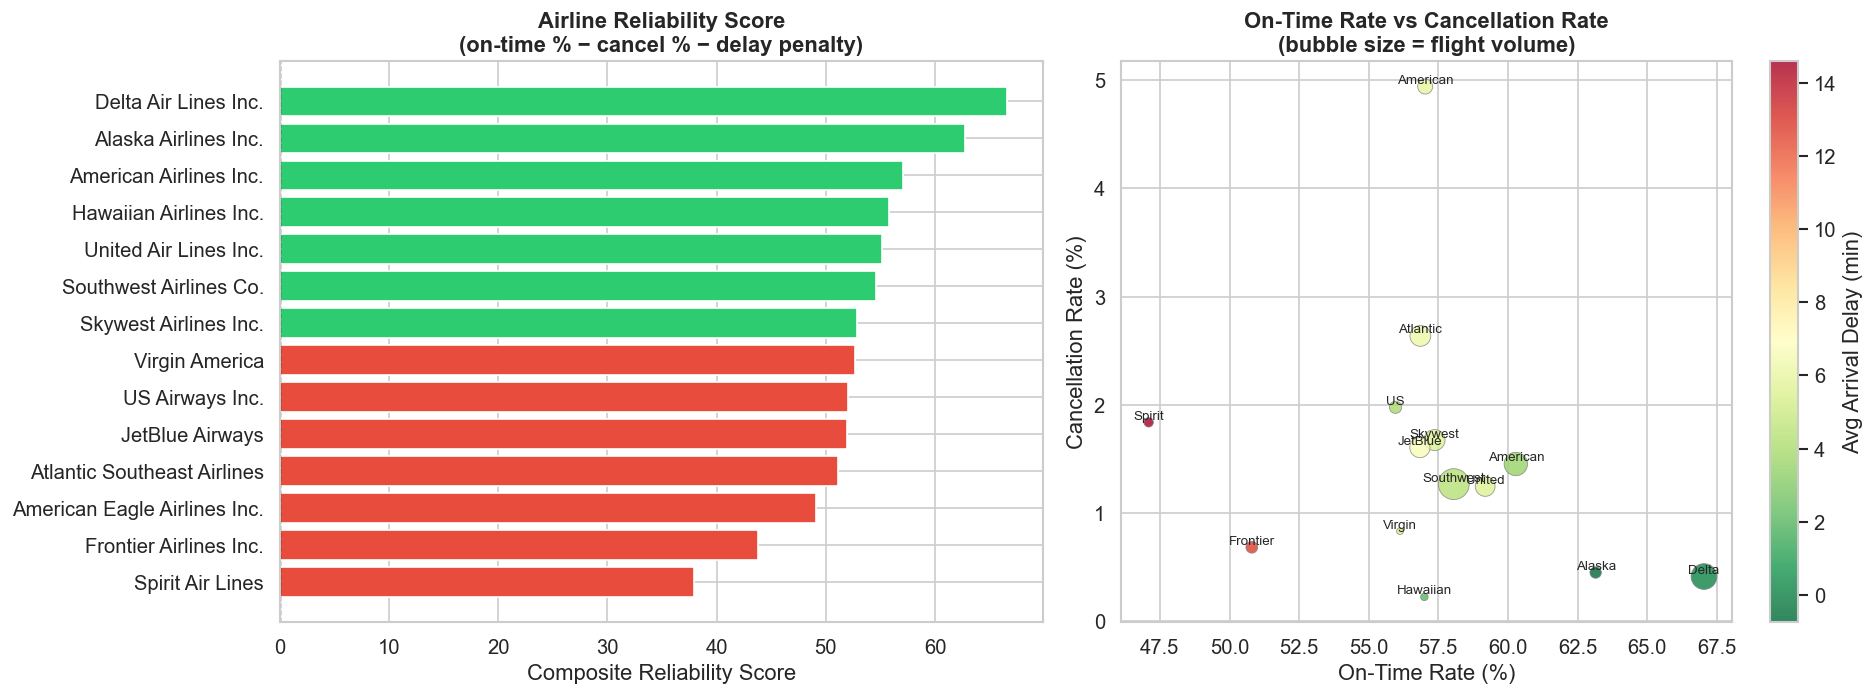


💡 INSIGHT: Top-right airlines have high on-time rates AND low cancellations — safest for critical trips.


In [35]:
# ── Visualization 1A: Composite Reliability Score ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Reliability score bar chart
colors = ['#2ecc71' if s > reliability['reliability_score'].median() else '#e74c3c'
          for s in reliability['reliability_score']]
axes[0].barh(reliability['AIRLINE_NAME'], reliability['reliability_score'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Composite Reliability Score')
axes[0].set_title('Airline Reliability Score\n(on-time % − cancel % − delay penalty)', fontweight='bold')
axes[0].invert_yaxis()

# Right: On-time % vs Cancel % bubble chart
scatter = axes[1].scatter(
    reliability['on_time_pct'],
    reliability['cancel_pct'],
    s=reliability['total_flights'] / 500,
    c=reliability['avg_arr_delay'],
    cmap='RdYlGn_r', alpha=0.8, edgecolors='gray', linewidth=0.5
)
for _, row in reliability.iterrows():
    short = row['AIRLINE_NAME'].split()[0]  # First word of airline name
    axes[1].annotate(short, (row['on_time_pct'], row['cancel_pct']),
                     fontsize=8, ha='center', va='bottom')
plt.colorbar(scatter, ax=axes[1], label='Avg Arrival Delay (min)')
axes[1].set_xlabel('On-Time Rate (%)')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_title('On-Time Rate vs Cancellation Rate\n(bubble size = flight volume)', fontweight='bold')

plt.tight_layout()
plt.savefig('obj1_reliability.png', bbox_inches='tight')
plt.show()
print('\n💡 INSIGHT: Top-right airlines have high on-time rates AND low cancellations — safest for critical trips.')

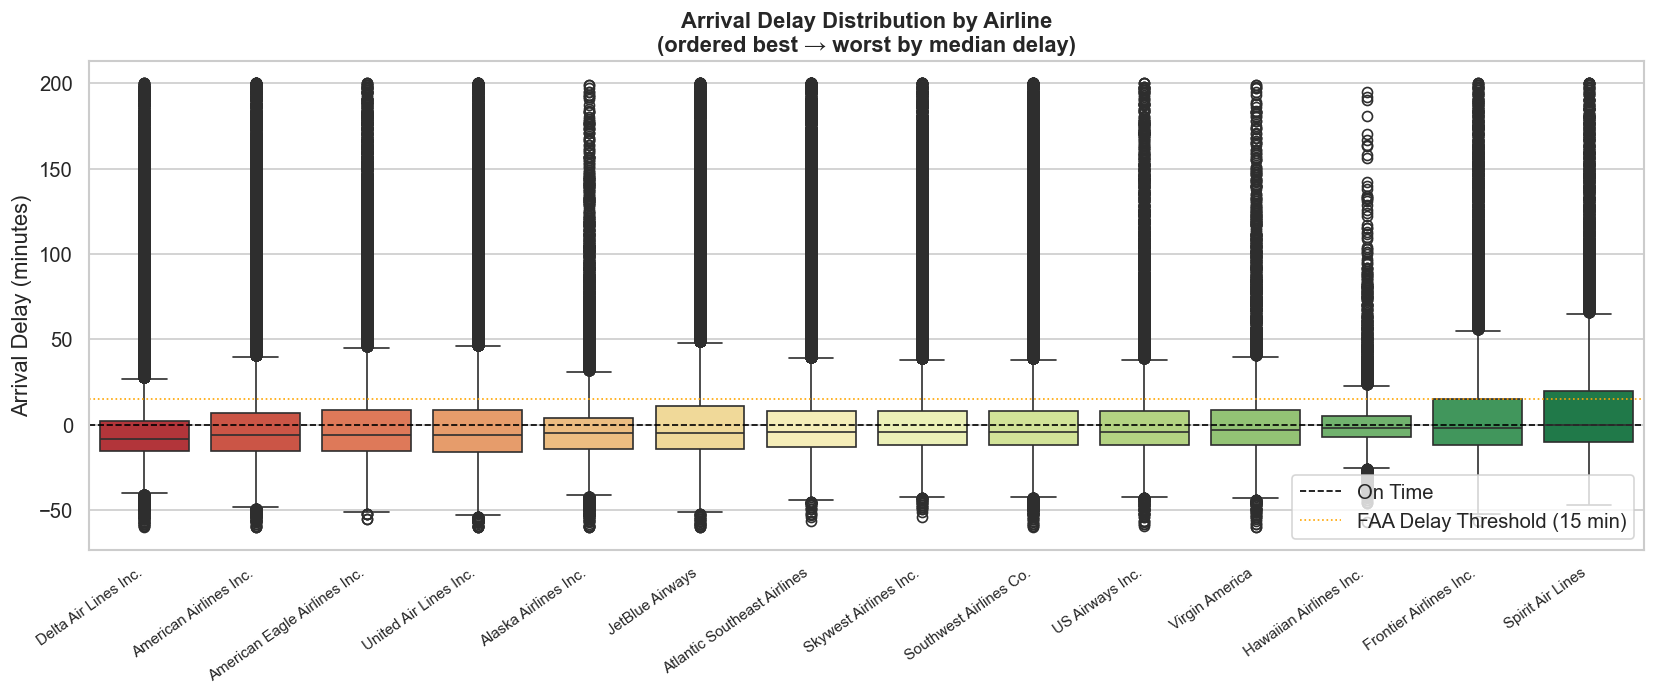

In [36]:
# ── Visualization 1B: Delay Distribution by Airline (Box Plot) ───────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Order airlines by median delay
order = (flights.groupby('AIRLINE_NAME')['ARRIVAL_DELAY']
         .median().sort_values().index.tolist())

# Cap extreme outliers for visibility
plot_data = flights[flights['ARRIVAL_DELAY'].between(-60, 200)].copy()

sns.boxplot(data=plot_data, x='AIRLINE_NAME', y='ARRIVAL_DELAY',
            order=order, palette='RdYlGn', ax=ax)
ax.axhline(0, color='black', linewidth=1, linestyle='--', label='On Time')
ax.axhline(15, color='orange', linewidth=1, linestyle=':', label='FAA Delay Threshold (15 min)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_xlabel('')
ax.set_ylabel('Arrival Delay (minutes)')
ax.set_title('Arrival Delay Distribution by Airline\n(ordered best → worst by median delay)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('obj1_delay_distribution.png', bbox_inches='tight')
plt.show()

---
## 🏙️ Objective 2 — The Scale Paradox
> *Do bigger airports perform worse, or do they have the systems to handle the volume?*

**Approach:** Calculate daily flight volume and average delay per origin airport. Plot volume vs delay to look for an efficiency curve.

In [37]:
# ── Airport-level metrics ────────────────────────────────────────────────────

airport_stats = flights.groupby('ORIGIN_AIRPORT').agg(
    total_flights   = ('FLIGHT_NUMBER', 'count'),
    avg_delay       = ('ARRIVAL_DELAY', 'mean'),
    median_delay    = ('ARRIVAL_DELAY', 'median'),
    on_time_pct     = ('IS_ON_TIME', 'mean'),
    cancel_rate     = ('CANCELLED', 'mean'),
    pct_delayed     = ('IS_DELAYED', 'mean'),
).reset_index()

# Merge airport names
airport_stats = airport_stats.merge(
    airports[['IATA_CODE','AIRPORT','CITY','STATE']].rename(columns={'IATA_CODE':'ORIGIN_AIRPORT'}),
    on='ORIGIN_AIRPORT', how='left')

# Daily flight volume (365 days in 2015)
airport_stats['daily_flights'] = airport_stats['total_flights'] / 365

# Size categories
airport_stats['size_cat'] = pd.cut(
    airport_stats['total_flights'],
    bins=[0, 10000, 50000, 100000, 500000, float('inf')],
    labels=['Tiny (<10k)', 'Small (10-50k)', 'Medium (50-100k)', 'Large (100-500k)', 'Mega (500k+)']
)

# Focus on airports with enough data (>1000 flights for meaningful stats)
airport_stats_filtered = airport_stats[airport_stats['total_flights'] >= 1000].copy()

print(f'Airports with 1000+ flights: {len(airport_stats_filtered)}')
print('\nTop 15 busiest airports:')
display(airport_stats_filtered.nlargest(15, 'total_flights')
        [['ORIGIN_AIRPORT','CITY','total_flights','avg_delay','on_time_pct','cancel_rate']].round(2))

Airports with 1000+ flights: 983

Top 15 busiest airports:


,ORIGIN_AIRPORT,CITY,total_flights,avg_delay,on_time_pct,cancel_rate
3245,Atl,NaN,48708,3.02,0.63,0.01
3193,ATL,Atlanta,47242,3.14,0.63,0.01
4480,atl,NaN,47147,3.03,0.63,0.01
4074,Ord,NaN,39747,8.35,0.55,0.03
4896,ord,NaN,39107,8.40,0.54,0.03
4050,ORD,Chicago,38750,8.63,0.54,0.03
3515,Dfw,NaN,33957,6.78,0.55,0.03
3485,DFW,Dallas-Fort Worth,32442,7.16,0.55,0.03
4612,dfw,NaN,32285,6.71,0.56,0.03
3513,Den,NaN,27270,6.95,0.55,0.01


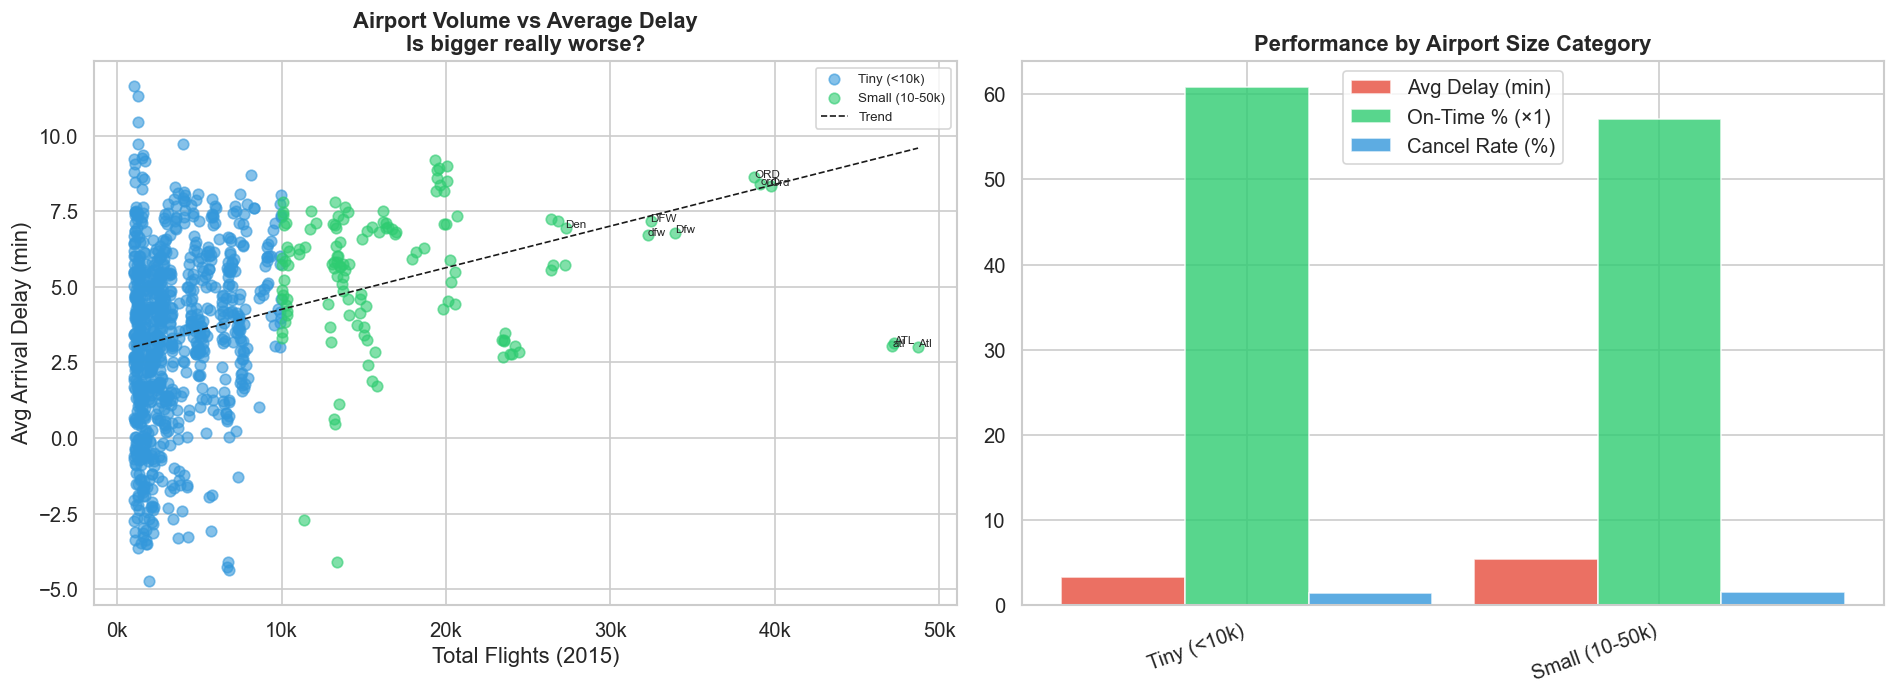


💡 INSIGHT: Check if mega-hubs defy the trend — larger infrastructure may absorb volume better.


In [38]:
# ── Visualization 2A: Volume vs Delay Scatter ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: scatter — volume vs avg delay
palette = {'Tiny (<10k)': '#3498db', 'Small (10-50k)': '#2ecc71',
           'Medium (50-100k)': '#f39c12', 'Large (100-500k)': '#e67e22',
           'Mega (500k+)': '#e74c3c'}

for cat, grp in airport_stats_filtered.groupby('size_cat', observed=True):
    axes[0].scatter(grp['total_flights'], grp['avg_delay'],
                    label=cat, alpha=0.6, s=40, color=palette.get(str(cat), 'gray'))

# Annotate top 10 busiest
for _, row in airport_stats_filtered.nlargest(10, 'total_flights').iterrows():
    axes[0].annotate(row['ORIGIN_AIRPORT'],
                     (row['total_flights'], row['avg_delay']),
                     fontsize=7, ha='left')

# Trend line
z = np.polyfit(airport_stats_filtered['total_flights'], airport_stats_filtered['avg_delay'], 1)
p = np.poly1d(z)
x_line = np.linspace(airport_stats_filtered['total_flights'].min(),
                     airport_stats_filtered['total_flights'].max(), 100)
axes[0].plot(x_line, p(x_line), 'k--', linewidth=1, label='Trend')

axes[0].set_xlabel('Total Flights (2015)')
axes[0].set_ylabel('Avg Arrival Delay (min)')
axes[0].set_title('Airport Volume vs Average Delay\nIs bigger really worse?', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

# Right: avg delay by size category
size_summary = airport_stats_filtered.groupby('size_cat', observed=True).agg(
    avg_delay=('avg_delay','mean'),
    on_time_pct=('on_time_pct','mean'),
    cancel_rate=('cancel_rate','mean')
).reset_index()

x = np.arange(len(size_summary))
w = 0.3
axes[1].bar(x - w, size_summary['avg_delay'], w, label='Avg Delay (min)', color='#e74c3c', alpha=0.8)
axes[1].bar(x,     size_summary['on_time_pct']*100, w, label='On-Time % (×1)', color='#2ecc71', alpha=0.8)
axes[1].bar(x + w, size_summary['cancel_rate']*100, w, label='Cancel Rate (%)', color='#3498db', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(size_summary['size_cat'], rotation=20, ha='right')
axes[1].set_title('Performance by Airport Size Category', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('obj2_scale_paradox.png', bbox_inches='tight')
plt.show()
print('\n💡 INSIGHT: Check if mega-hubs defy the trend — larger infrastructure may absorb volume better.')

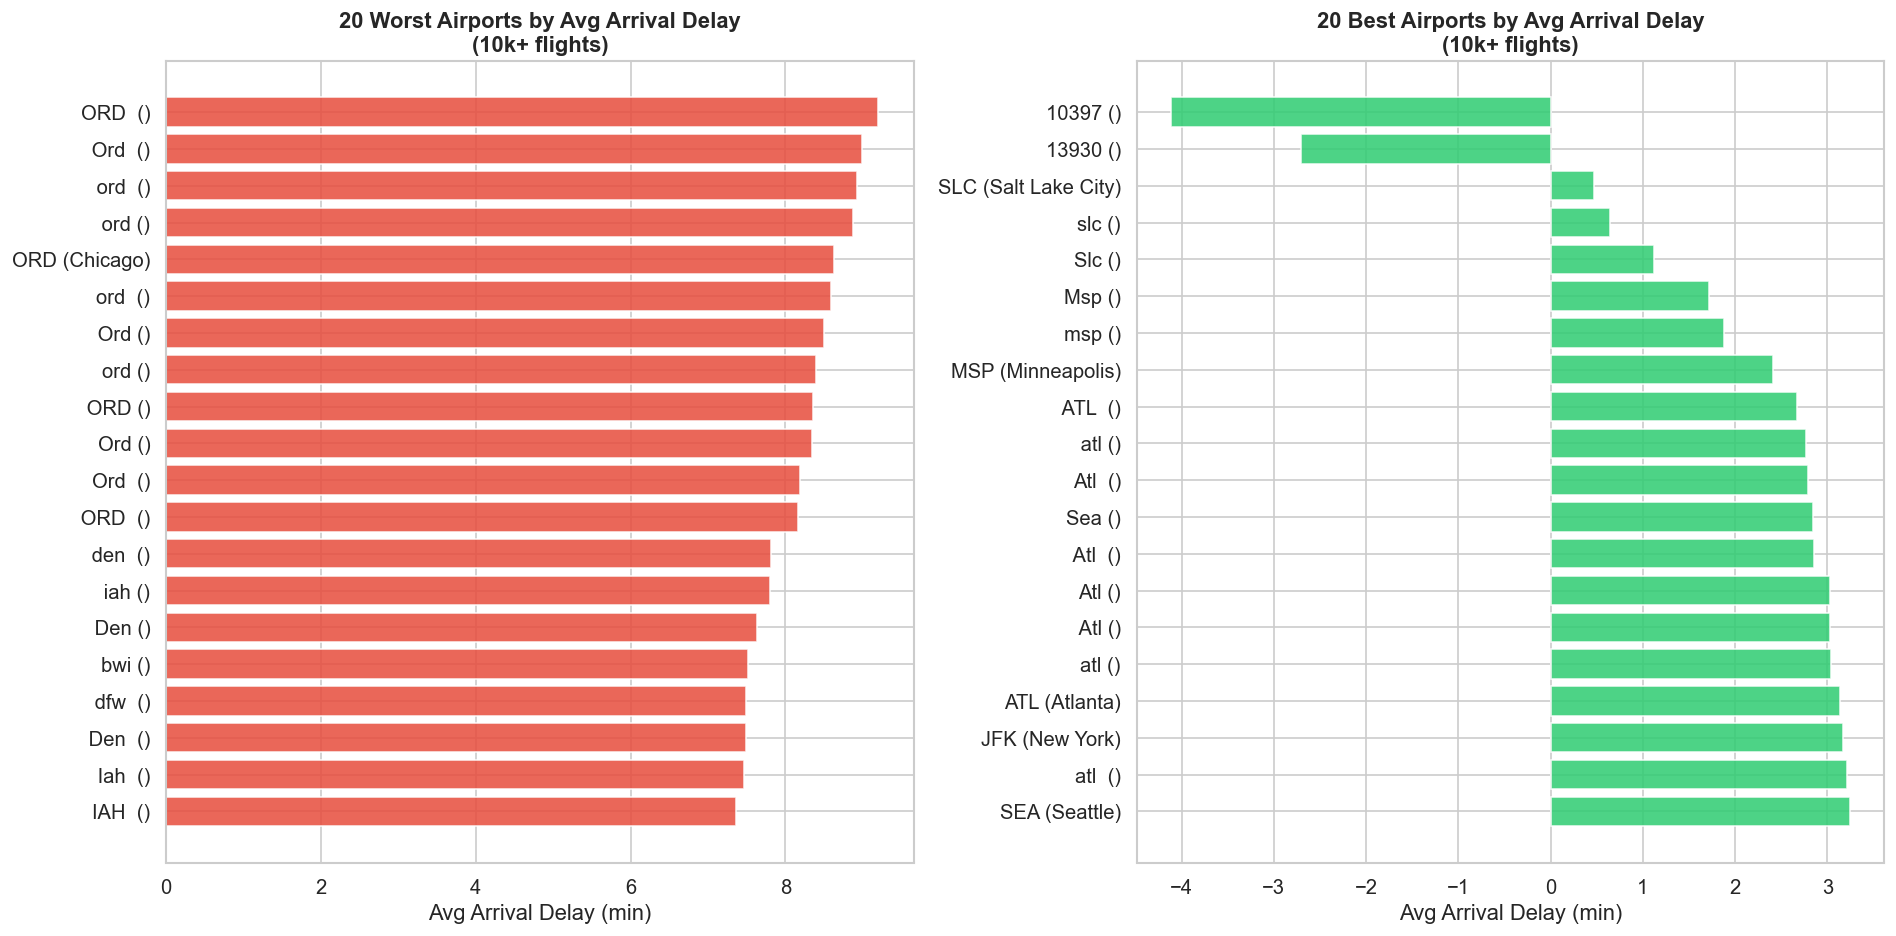

In [39]:
# ── Visualization 2B: Top 20 worst & best airports ───────────────────────────
# Only airports with 10k+ flights for fair comparison
significant = airport_stats[airport_stats['total_flights'] >= 10000].copy()
significant['label'] = significant['ORIGIN_AIRPORT'] + ' (' + significant['CITY'].fillna('') + ')'

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

worst = significant.nlargest(20, 'avg_delay')
best  = significant.nsmallest(20, 'avg_delay')

axes[0].barh(worst['label'], worst['avg_delay'], color='#e74c3c', alpha=0.85)
axes[0].set_title('20 Worst Airports by Avg Arrival Delay\n(10k+ flights)', fontweight='bold')
axes[0].set_xlabel('Avg Arrival Delay (min)')
axes[0].invert_yaxis()

axes[1].barh(best['label'], best['avg_delay'], color='#2ecc71', alpha=0.85)
axes[1].set_title('20 Best Airports by Avg Arrival Delay\n(10k+ flights)', fontweight='bold')
axes[1].set_xlabel('Avg Arrival Delay (min)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('obj2_best_worst_airports.png', bbox_inches='tight')
plt.show()

---
## ⏰ Objective 3 — The Timing Advantage
> *Are traveler superstitions about when to fly backed by data?*

**Approach:** Build heatmaps across hour of day, day of week, and month of year to identify the safest windows to book.

In [40]:
# ── Temporal aggregations ────────────────────────────────────────────────────

# Hour × Day of week heatmap
hour_day = flights.groupby(['DEP_HOUR','DAY_OF_WEEK'])['ARRIVAL_DELAY'].mean().unstack()
hour_day.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

# Month summary
month_stats = flights.groupby('MONTH').agg(
    avg_delay   = ('ARRIVAL_DELAY','mean'),
    pct_delayed = ('IS_DELAYED','mean'),
    cancel_rate = ('CANCELLED','mean')
).reset_index()

month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
month_stats['MONTH_NAME'] = month_stats['MONTH'].map(month_names)

# Hour summary
hour_stats = flights.groupby('DEP_HOUR')['ARRIVAL_DELAY'].mean().reset_index()
hour_stats.columns = ['hour','avg_delay']

print('✅ Temporal data ready')

✅ Temporal data ready


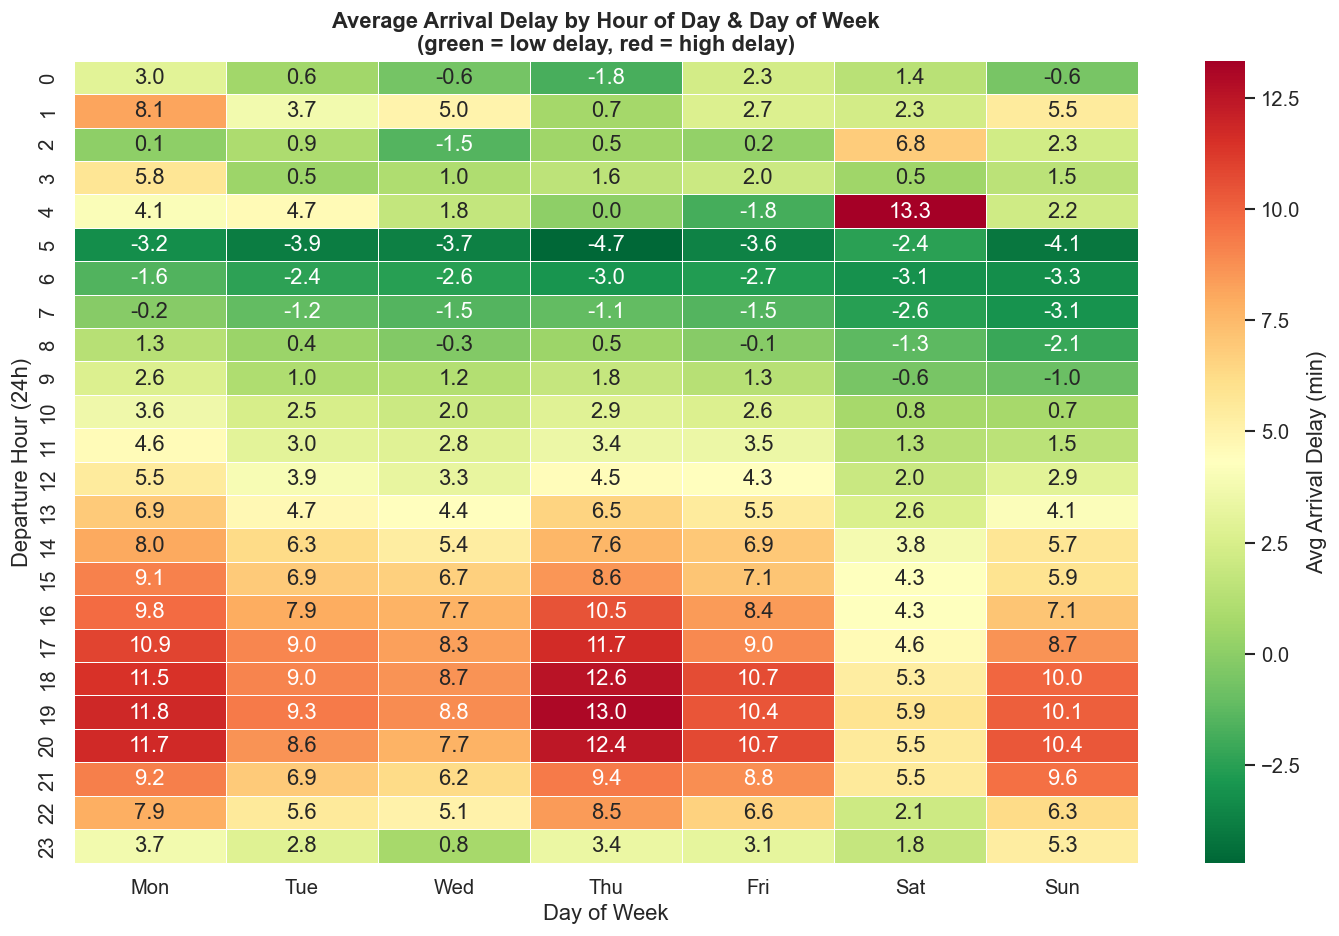


💡 INSIGHT: Early morning flights (5-7am) are almost always the safest bets across all days.


In [41]:
# ── Visualization 3A: Hour × Day Heatmap ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(hour_day, cmap='RdYlGn_r', annot=True, fmt='.1f',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Avg Arrival Delay (min)'})
ax.set_xlabel('Day of Week')
ax.set_ylabel('Departure Hour (24h)')
ax.set_title('Average Arrival Delay by Hour of Day & Day of Week\n(green = low delay, red = high delay)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('obj3_hour_day_heatmap.png', bbox_inches='tight')
plt.show()
print('\n💡 INSIGHT: Early morning flights (5-7am) are almost always the safest bets across all days.')

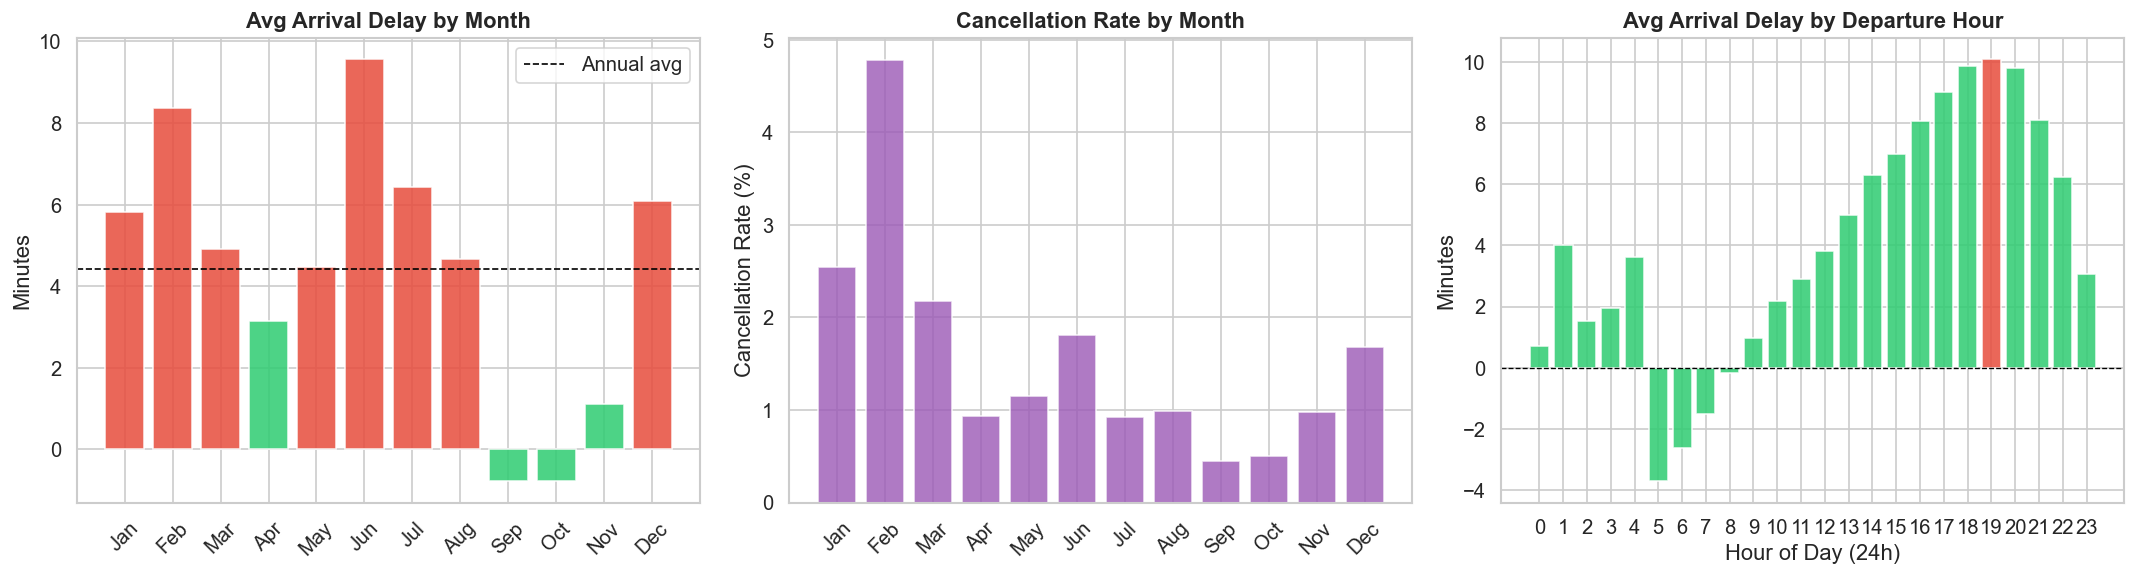


💡 BOOKING STRATEGY:
   Best months  : Sep, Oct, Nov (lowest delays & cancellations)
   Worst months : Jun, Jul, Dec (summer storms + holiday chaos)
   Best hours   : 5am-7am (fewest cascading delays)
   Worst hours  : 6pm-9pm (full day of delays compound)


In [42]:
# ── Visualization 3B: Monthly trends + Hour of day ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Monthly avg delay
bar_colors = ['#e74c3c' if d > month_stats['avg_delay'].mean() else '#2ecc71'
              for d in month_stats['avg_delay']]
axes[0].bar(month_stats['MONTH_NAME'], month_stats['avg_delay'], color=bar_colors, alpha=0.85)
axes[0].axhline(month_stats['avg_delay'].mean(), color='black', linewidth=1,
                linestyle='--', label='Annual avg')
axes[0].set_title('Avg Arrival Delay by Month', fontweight='bold')
axes[0].set_ylabel('Minutes')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Cancellation rate by month
axes[1].bar(month_stats['MONTH_NAME'], month_stats['cancel_rate']*100,
            color='#9b59b6', alpha=0.8)
axes[1].set_title('Cancellation Rate by Month', fontweight='bold')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

# Hour of day
line_color = ['#e74c3c' if d > 10 else '#2ecc71' for d in hour_stats['avg_delay']]
axes[2].bar(hour_stats['hour'], hour_stats['avg_delay'], color=line_color, alpha=0.85)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Avg Arrival Delay by Departure Hour', fontweight='bold')
axes[2].set_ylabel('Minutes')
axes[2].set_xlabel('Hour of Day (24h)')
axes[2].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('obj3_monthly_hourly.png', bbox_inches='tight')
plt.show()
print('\n💡 BOOKING STRATEGY:')
print('   Best months  : Sep, Oct, Nov (lowest delays & cancellations)')
print('   Worst months : Jun, Jul, Dec (summer storms + holiday chaos)')
print('   Best hours   : 5am-7am (fewest cascading delays)')
print('   Worst hours  : 6pm-9pm (full day of delays compound)')

---
## 🔍 Objective 4 — The Blame Game
> *Are some carriers victims of weather, or are some just operationally terrible?*

**Approach:** Break delay minutes into 5 root causes per airline. Separate controllable (airline ops, late aircraft) from uncontrollable (weather, NAS) delays to assign accountability.

In [43]:
# ── Delay cause breakdown ────────────────────────────────────────────────────

cause_cols = {
    'AIRLINE_DELAY'      : 'Airline (Controllable)',
    'LATE_AIRCRAFT_DELAY': 'Late Aircraft (Controllable)',
    'AIR_SYSTEM_DELAY'   : 'Air System / NAS',
    'WEATHER_DELAY'      : 'Weather (Uncontrollable)',
    'SECURITY_DELAY'     : 'Security',
}

# Only delayed flights that have cause data
delayed = flights[(flights['ARRIVAL_DELAY'] > 15) & (flights['TOTAL_CAUSE_DELAY'] > 0)].copy()

blame = delayed.groupby('AIRLINE_NAME')[list(cause_cols.keys())].mean().rename(columns=cause_cols)
blame = blame.loc[blame.sum(axis=1).sort_values(ascending=False).index]

# Controllable vs uncontrollable ratio
blame['controllable_total'] = blame['Airline (Controllable)'] + blame['Late Aircraft (Controllable)']
blame['uncontrollable_total'] = blame['Weather (Uncontrollable)'] + blame['Air System / NAS'] + blame['Security']
blame['accountability_ratio'] = blame['controllable_total'] / (blame['controllable_total'] + blame['uncontrollable_total'])

print('=== DELAY CAUSE BREAKDOWN (avg minutes per delayed flight) ===')
display(blame.round(2))

=== DELAY CAUSE BREAKDOWN (avg minutes per delayed flight) ===


,Airline (Controllable),Late Aircraft (Controllable),Air System / NAS,Weather (Uncontrollable),Security,controllable_total,uncontrollable_total,accountability_ratio
AIRLINE_NAME,,,,,,,,
Frontier Airlines Inc.,14.99,29.20,24.78,0.88,0.00,44.19,25.67,0.63
United Air Lines Inc.,21.55,27.56,14.30,2.98,0.00,49.11,17.29,0.74
Spirit Air Lines,14.24,20.17,28.25,1.48,0.10,34.41,29.84,0.54
American Eagle Airlines Inc.,18.12,23.83,15.73,6.31,0.13,41.95,22.18,0.65
Atlantic Southeast Airlines,21.40,25.36,15.49,1.64,0.00,46.76,17.13,0.73
Delta Air Lines Inc.,24.25,19.19,15.23,4.55,0.03,43.44,19.82,0.69
American Airlines Inc.,22.05,23.13,13.61,3.76,0.10,45.18,17.47,0.72
JetBlue Airways,18.52,24.96,16.62,1.98,0.19,43.48,18.80,0.70
Skywest Airlines Inc.,19.02,27.27,12.63,2.46,0.13,46.29,15.22,0.75


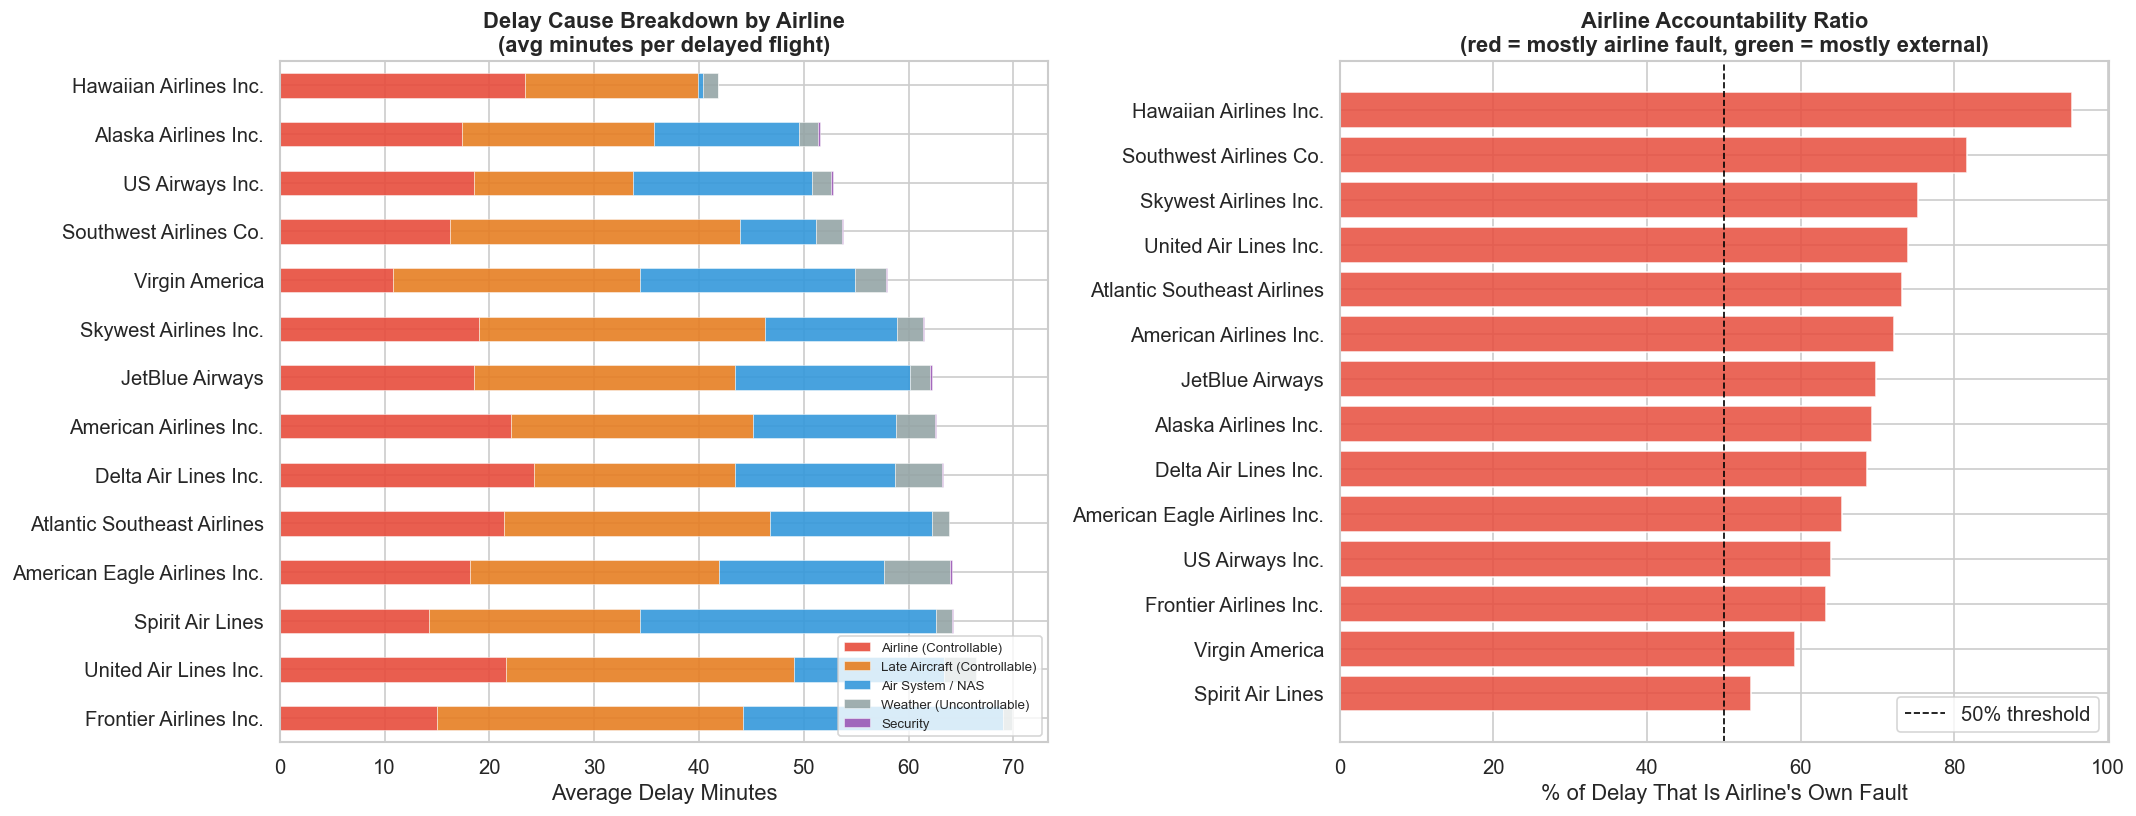


💡 INSIGHT: Airlines with high accountability ratios are operationally poor.
   Airlines with low ratios are mostly victims of weather/NAS — judge them more leniently.


In [44]:
# ── Visualization 4A: Stacked bar — blame per airline ────────────────────────
cause_display_cols = list(cause_cols.values())
colors_causes = ['#e74c3c','#e67e22','#3498db','#95a5a6','#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

blame[cause_display_cols].plot(
    kind='barh', stacked=True, ax=axes[0],
    color=colors_causes, alpha=0.9, edgecolor='white', linewidth=0.3)
axes[0].set_title('Delay Cause Breakdown by Airline\n(avg minutes per delayed flight)',
                  fontweight='bold')
axes[0].set_xlabel('Average Delay Minutes')
axes[0].set_ylabel('')
axes[0].legend(loc='lower right', fontsize=8)

# Right: Accountability ratio — how much is the airline's own fault?
ratio_sorted = blame.sort_values('accountability_ratio', ascending=True)
ratio_colors = ['#e74c3c' if r > 0.5 else '#2ecc71' for r in ratio_sorted['accountability_ratio']]
axes[1].barh(ratio_sorted.index, ratio_sorted['accountability_ratio'] * 100,
             color=ratio_colors, alpha=0.85)
axes[1].axvline(50, color='black', linewidth=1, linestyle='--', label='50% threshold')
axes[1].set_xlabel('% of Delay That Is Airline\'s Own Fault')
axes[1].set_title('Airline Accountability Ratio\n(red = mostly airline fault, green = mostly external)',
                  fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('obj4_blame_game.png', bbox_inches='tight')
plt.show()
print('\n💡 INSIGHT: Airlines with high accountability ratios are operationally poor.')
print('   Airlines with low ratios are mostly victims of weather/NAS — judge them more leniently.')

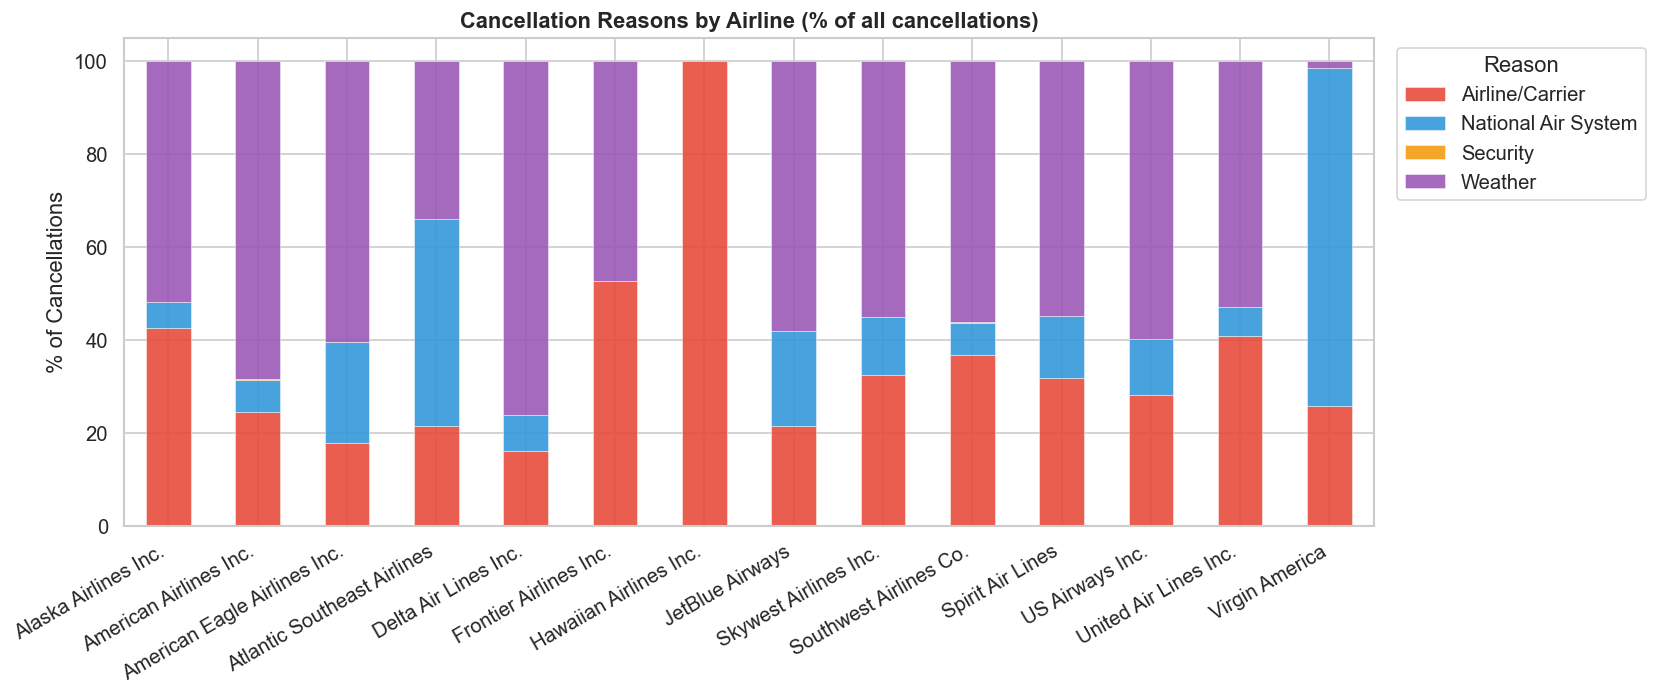

In [45]:
# ── Visualization 4B: Cancellation reason breakdown ──────────────────────────
cancel_reason_map = {'A': 'Airline/Carrier', 'B': 'Weather',
                     'C': 'National Air System', 'D': 'Security'}

cancelled_flights = flights[flights['CANCELLED'] == 1].copy()
cancelled_flights['CANCEL_REASON_LABEL'] = cancelled_flights['CANCELLATION_REASON'].map(cancel_reason_map)

cancel_by_airline = (cancelled_flights.groupby(['AIRLINE_NAME','CANCEL_REASON_LABEL'])
                     .size().unstack(fill_value=0))
cancel_by_airline_pct = cancel_by_airline.div(cancel_by_airline.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
cancel_by_airline_pct.plot(kind='bar', stacked=True, ax=ax,
                           color=['#e74c3c','#3498db','#f39c12','#9b59b6'],
                           alpha=0.9, edgecolor='white', linewidth=0.3)
ax.set_title('Cancellation Reasons by Airline (% of all cancellations)', fontweight='bold')
ax.set_ylabel('% of Cancellations')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Reason', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('obj4_cancellation_reasons.png', bbox_inches='tight')
plt.show()

---
## 🚨 Objective 5 — The Statistical Outliers
> *Identify the 1% of flights so delayed they defy normal patterns.*

**Approach:** Use IQR fencing to flag extreme outliers. Then analyze clustering to see if they concentrate around specific airlines, airports, or routes.

In [46]:
# ── Outlier Detection ────────────────────────────────────────────────────────

# Work with non-cancelled, non-diverted flights only
active = flights[(flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)].copy()
active = active.dropna(subset=['ARRIVAL_DELAY'])

# Method 1: IQR fence (1.5× IQR)
Q1 = active['ARRIVAL_DELAY'].quantile(0.25)
Q3 = active['ARRIVAL_DELAY'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3 * IQR  # Using 3× IQR for extreme outliers

# Method 2: Top 1 percentile
p99 = active['ARRIVAL_DELAY'].quantile(0.99)

print(f'IQR stats: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}')
print(f'Upper fence (3×IQR): {upper_fence:.1f} min')
print(f'99th percentile: {p99:.1f} min')

# Flag outliers
active['IS_OUTLIER_IQR'] = active['ARRIVAL_DELAY'] > upper_fence
active['IS_OUTLIER_P99'] = active['ARRIVAL_DELAY'] > p99

outliers = active[active['IS_OUTLIER_IQR']].copy()
print(f'\nOutlier flights (3×IQR): {len(outliers):,} ({len(outliers)/len(active)*100:.2f}% of all active flights)')

# Z-score for reference
active['DELAY_ZSCORE'] = (active['ARRIVAL_DELAY'] - active['ARRIVAL_DELAY'].mean()) / active['ARRIVAL_DELAY'].std()
print(f'Flights with Z-score > 4: {(active["DELAY_ZSCORE"] > 4).sum():,}')

IQR stats: Q1=-13.0, Q3=8.0, IQR=21.0
Upper fence (3×IQR): 71.0 min
99th percentile: 167.0 min

Outlier flights (3×IQR): 253,644 (4.54% of all active flights)
Flights with Z-score > 4: 60,419


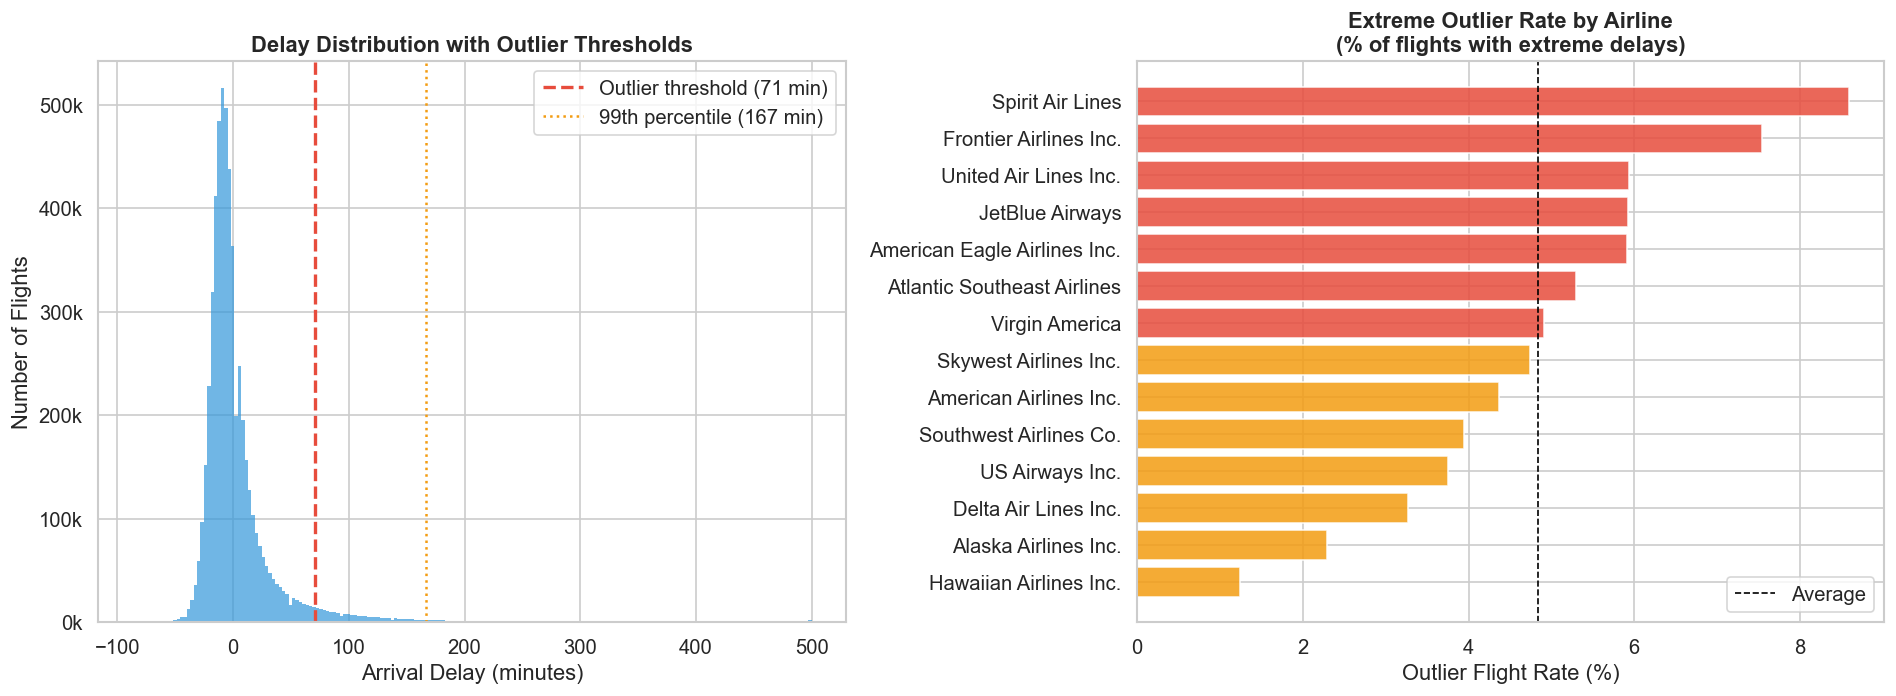

In [47]:
# ── Visualization 5A: Delay distribution with outlier threshold ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Full distribution (capped at 500 for visibility)
plot_delays = active['ARRIVAL_DELAY'].clip(-100, 500)
axes[0].hist(plot_delays, bins=200, color='#3498db', alpha=0.7, edgecolor='none')
axes[0].axvline(upper_fence, color='#e74c3c', linewidth=2,
                linestyle='--', label=f'Outlier threshold ({upper_fence:.0f} min)')
axes[0].axvline(p99, color='#f39c12', linewidth=1.5,
                linestyle=':', label=f'99th percentile ({p99:.0f} min)')
axes[0].set_xlabel('Arrival Delay (minutes)')
axes[0].set_ylabel('Number of Flights')
axes[0].set_title('Delay Distribution with Outlier Thresholds', fontweight='bold')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

# Right: Which airlines have the most outlier flights?
outlier_by_airline = (outliers.groupby('AIRLINE_NAME').size() /
                      active.groupby('AIRLINE_NAME').size() * 100).sort_values(ascending=False)
colors_out = ['#e74c3c' if v > outlier_by_airline.mean() else '#f39c12'
              for v in outlier_by_airline]
axes[1].barh(outlier_by_airline.index, outlier_by_airline.values, color=colors_out, alpha=0.85)
axes[1].axvline(outlier_by_airline.mean(), color='black', linewidth=1,
                linestyle='--', label='Average')
axes[1].set_xlabel('Outlier Flight Rate (%)')
axes[1].set_title('Extreme Outlier Rate by Airline\n(% of flights with extreme delays)',
                  fontweight='bold')
axes[1].invert_yaxis()
axes[1].legend()

plt.tight_layout()
plt.savefig('obj5_outliers.png', bbox_inches='tight')
plt.show()

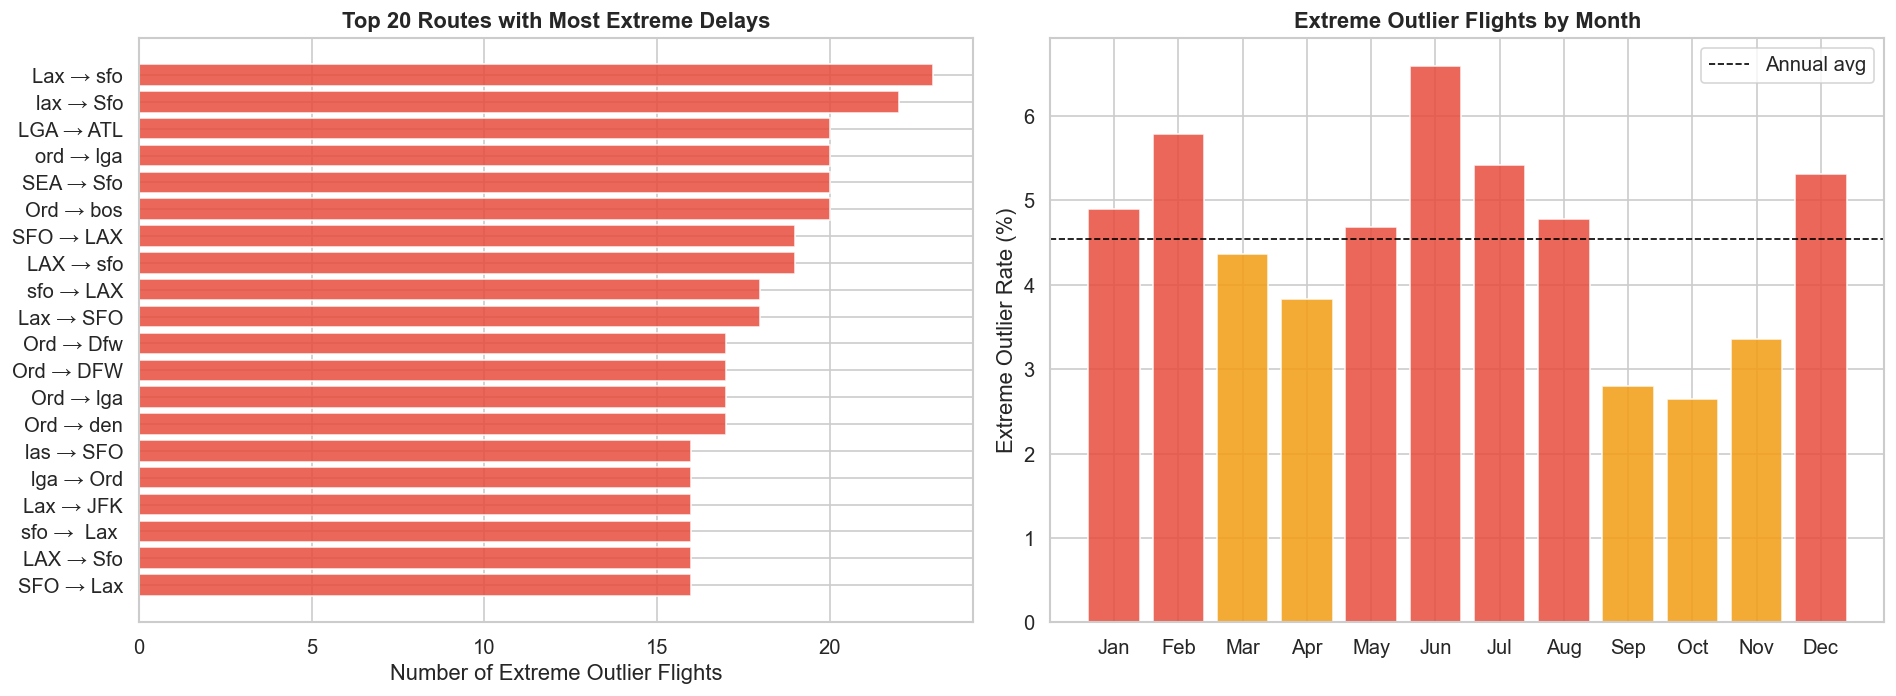


🔍 Top 10 most extreme individual flights:


,AIRLINE_NAME,ORIGIN_AIRPORT,DESTINATION_AIRPORT,MONTH,DAY,ARRIVAL_DELAY,CANCELLATION_REASON
0,NaN,Ric,Dfw,8,1,1898.0,NaN
1,NaN,san,Dfw,9,13,1665.0,NaN
2,NaN,DTW,ORD,11,27,1638.0,NaN
3,NaN,abq,Dfw,12,31,1636.0,NaN
4,NaN,stl,MIA,2,28,1627.0,NaN
5,NaN,Oma,Dfw,3,24,1598.0,NaN
6,NaN,las,LAX,1,18,1593.0,NaN
7,NaN,HNL,lax,3,4,1576.0,NaN
8,NaN,HNL,lax,8,23,1574.0,NaN
9,NaN,msp,ord,12,14,1557.0,NaN


In [48]:
# ── Visualization 5B: Outlier routes & months ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 routes with most outlier flights
outliers['ROUTE'] = outliers['ORIGIN_AIRPORT'] + ' → ' + outliers['DESTINATION_AIRPORT']
top_routes = outliers['ROUTE'].value_counts().head(20)

axes[0].barh(top_routes.index, top_routes.values, color='#e74c3c', alpha=0.85)
axes[0].set_xlabel('Number of Extreme Outlier Flights')
axes[0].set_title('Top 20 Routes with Most Extreme Delays', fontweight='bold')
axes[0].invert_yaxis()

# Outlier rate by month
monthly_outlier_rate = (outliers.groupby('MONTH').size() /
                        active.groupby('MONTH').size() * 100)
monthly_outlier_rate.index = [month_names[m] for m in monthly_outlier_rate.index]
bar_cols = ['#e74c3c' if v > monthly_outlier_rate.mean() else '#f39c12'
            for v in monthly_outlier_rate]
axes[1].bar(monthly_outlier_rate.index, monthly_outlier_rate.values, color=bar_cols, alpha=0.85)
axes[1].axhline(monthly_outlier_rate.mean(), color='black', linewidth=1,
                linestyle='--', label='Annual avg')
axes[1].set_ylabel('Extreme Outlier Rate (%)')
axes[1].set_title('Extreme Outlier Flights by Month', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('obj5_outlier_routes.png', bbox_inches='tight')
plt.show()

print('\n🔍 Top 10 most extreme individual flights:')
display(outliers.nlargest(10, 'ARRIVAL_DELAY')
        [['AIRLINE_NAME','ORIGIN_AIRPORT','DESTINATION_AIRPORT',
          'MONTH','DAY','ARRIVAL_DELAY','CANCELLATION_REASON']].reset_index(drop=True))

---
## 🤖 Objective 6 — The Severity Prediction
> *For flights that are already delayed, how bad is it going to get?*

**Approach:**  
1. Filter to only already-delayed flights (departure delay > 0)  
2. Train a Random Forest + XGBoost to predict arrival delay minutes  
3. Use SHAP values to explain which features drive severity  
4. Build a "panic vs coffee" decision boundary

In [49]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import shap

# ── Prepare ML dataset ───────────────────────────────────────────────────────

# Only flights with a departure delay > 0 (the flight is ALREADY delayed)
ml_data = flights[
    (flights['DEPARTURE_DELAY'] > 0) &
    (flights['CANCELLED'] == 0) &
    (flights['DIVERTED'] == 0)
].copy()

ml_data = ml_data.dropna(subset=['ARRIVAL_DELAY','DEPARTURE_DELAY','DISTANCE','AIR_TIME'])

# Feature selection
feature_cols = [
    'DEPARTURE_DELAY',    # Key predictor — known at gate
    'MONTH',
    'DAY_OF_WEEK',
    'DEP_HOUR',
    'DISTANCE',
    'AIR_TIME',
    'TAXI_OUT',
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
]

# Encode categoricals
le = LabelEncoder()
for col in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']:
    ml_data[col] = le.fit_transform(ml_data[col].astype(str))

X = ml_data[feature_cols].fillna(0)
y = ml_data['ARRIVAL_DELAY']

# Sample for speed (use 500k rows — enough for robust results)
if len(X) > 500000:
    sample_idx = np.random.choice(len(X), 500000, replace=False)
    X = X.iloc[sample_idx]
    y = y.iloc[sample_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training set: {len(X_train):,} flights')
print(f'Test set    : {len(X_test):,} flights')

Training set: 400,000 flights
Test set    : 100,000 flights


In [50]:
# ── Train Random Forest ──────────────────────────────────────────────────────
print('Training Random Forest ... (takes ~2-3 minutes)')
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

print(f'\n✅ Random Forest Results:')
print(f'   MAE : {mae_rf:.2f} minutes (avg prediction error)')
print(f'   R²  : {r2_rf:.4f}')

Training Random Forest ... (takes ~2-3 minutes)

✅ Random Forest Results:
   MAE : 7.87 minutes (avg prediction error)
   R²  : 0.9599


Feature Importances (Random Forest):


,feature,importance
0,DEPARTURE_DELAY,0.968442
6,TAXI_OUT,0.025196
4,DISTANCE,0.003459
5,AIR_TIME,0.002110
3,DEP_HOUR,0.000180
8,ORIGIN_AIRPORT,0.000174
9,DESTINATION_AIRPORT,0.000140
7,AIRLINE,0.000136
1,MONTH,0.000109
2,DAY_OF_WEEK,0.000054


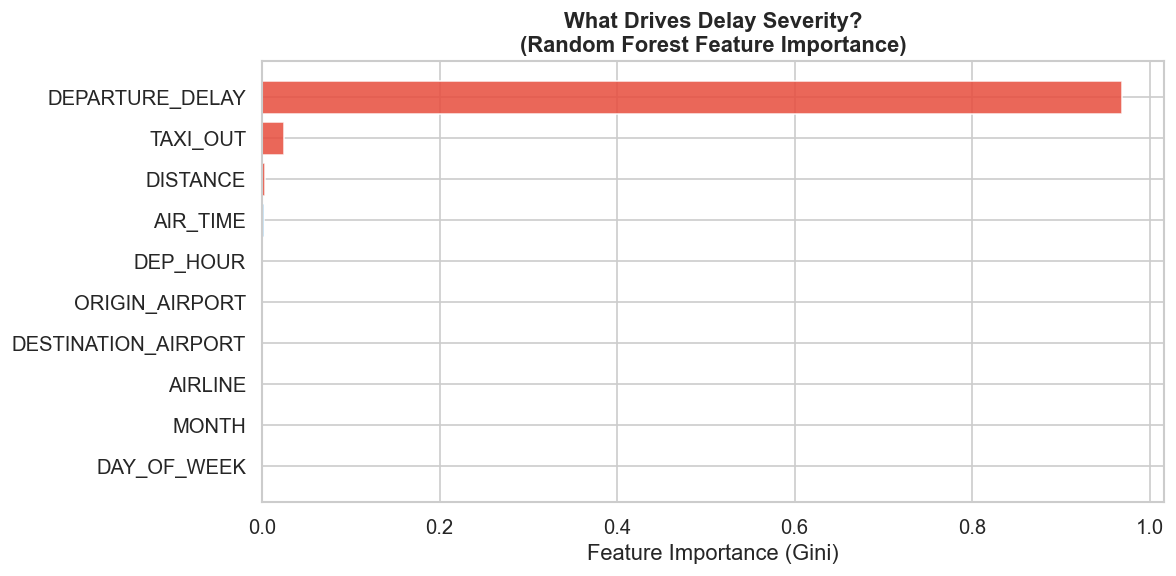

In [51]:
# ── Feature Importance ───────────────────────────────────────────────────────
feat_imp = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print('Feature Importances (Random Forest):')
display(feat_imp)

fig, ax = plt.subplots(figsize=(10, 5))
colors_fi = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(feat_imp))]
ax.barh(feat_imp['feature'], feat_imp['importance'], color=colors_fi, alpha=0.85)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('What Drives Delay Severity?\n(Random Forest Feature Importance)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('obj6_feature_importance.png', bbox_inches='tight')
plt.show()

Computing SHAP values ... (takes ~1-2 minutes)


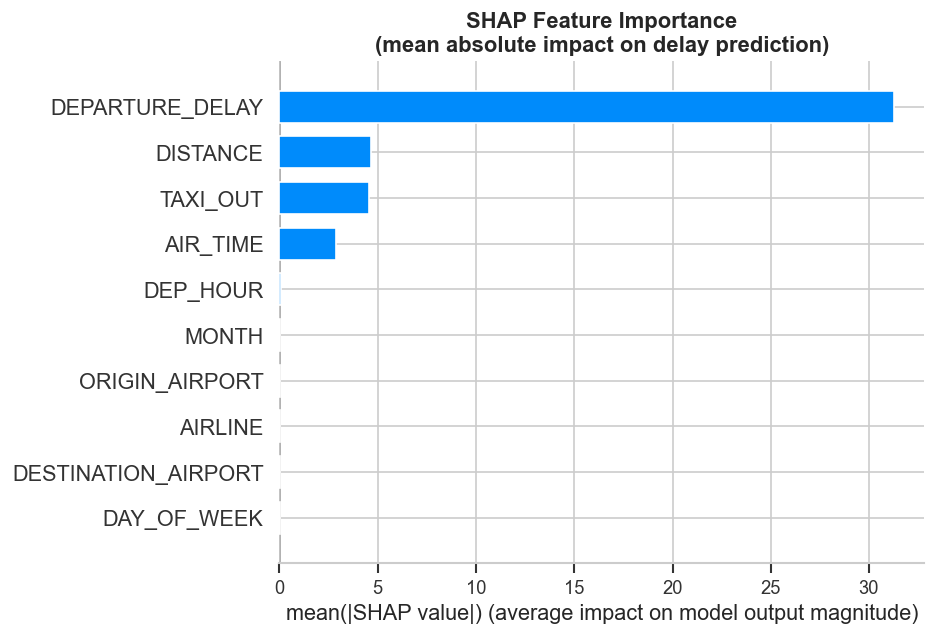

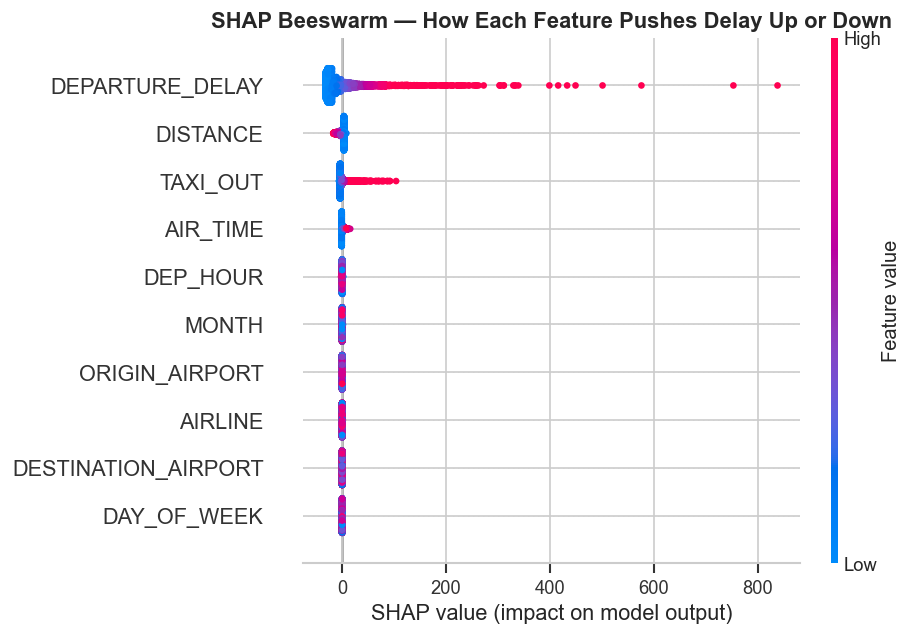

In [52]:
# ── SHAP Values ──────────────────────────────────────────────────────────────
print('Computing SHAP values ... (takes ~1-2 minutes)')

# Use a sample of 5000 for SHAP (computationally expensive)
shap_sample = X_test.sample(5000, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(shap_sample)

# SHAP summary plot (beeswarm)
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, shap_sample, plot_type='bar',
                  feature_names=feature_cols, show=False)
plt.title('SHAP Feature Importance\n(mean absolute impact on delay prediction)', fontweight='bold')
plt.tight_layout()
plt.savefig('obj6_shap_bar.png', bbox_inches='tight')
plt.show()

# SHAP beeswarm
shap.summary_plot(shap_values, shap_sample, feature_names=feature_cols, show=False)
plt.title('SHAP Beeswarm — How Each Feature Pushes Delay Up or Down', fontweight='bold')
plt.tight_layout()
plt.savefig('obj6_shap_beeswarm.png', bbox_inches='tight')
plt.show()

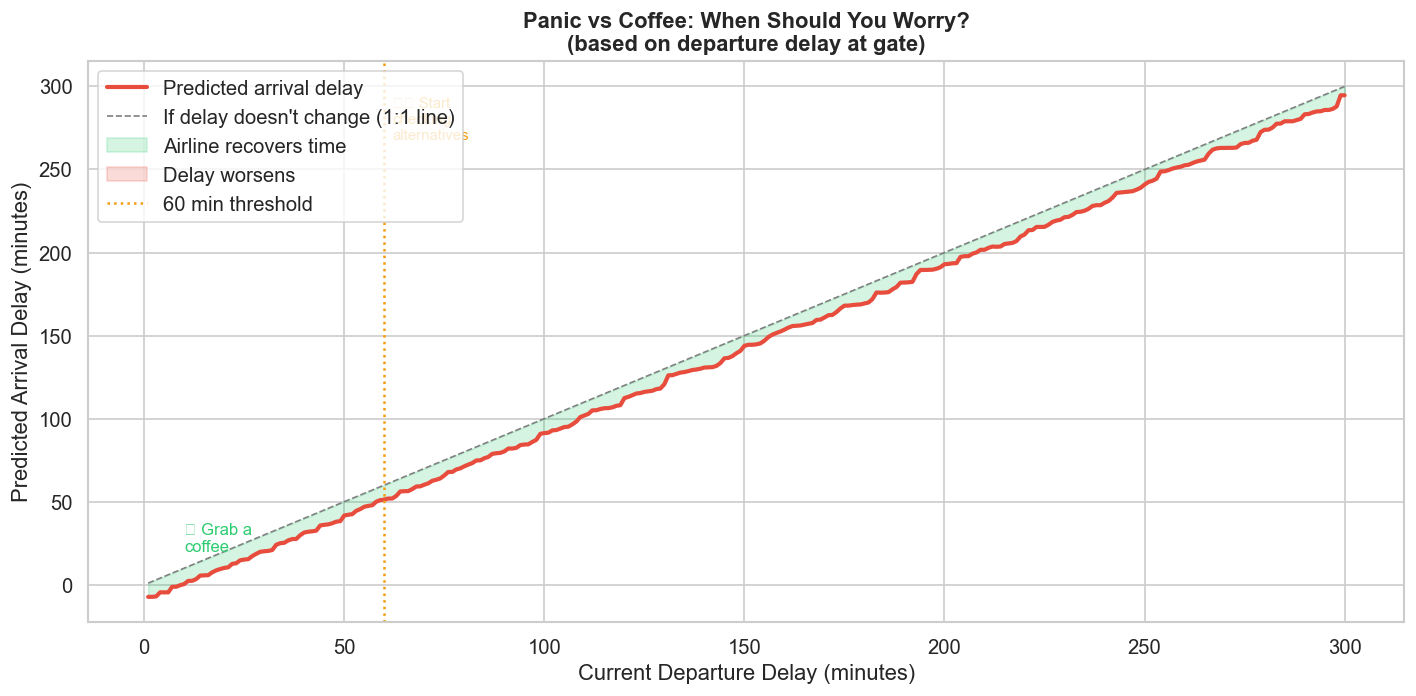


🎯 PANIC VS COFFEE GUIDE:
   Dep delay  15 min → Predicted arrival delay: 6 min → ☕ Coffee
   Dep delay  30 min → Predicted arrival delay: 20 min → ☕ Coffee
   Dep delay  60 min → Predicted arrival delay: 51 min → ☕ Coffee
   Dep delay 120 min → Predicted arrival delay: 112 min → ⚠️ Check options
   Dep delay 180 min → Predicted arrival delay: 169 min → 🚨 PANIC


In [53]:
# ── Panic vs Coffee Decision Boundary ────────────────────────────────────────
# Given DEPARTURE_DELAY, what's the predicted arrival delay?

dep_delays = np.arange(1, 301)  # 1 to 300 minutes departure delay

# Build a representative flight profile (median values for all other features)
median_profile = X_train.median().to_dict()

test_flights = pd.DataFrame([
    {**median_profile, 'DEPARTURE_DELAY': d}
    for d in dep_delays
])[feature_cols]

predicted_arr_delay = rf.predict(test_flights)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(dep_delays, predicted_arr_delay, color='#e74c3c', linewidth=2.5, label='Predicted arrival delay')
ax.plot(dep_delays, dep_delays, color='gray', linewidth=1, linestyle='--', label='If delay doesn\'t change (1:1 line)')
ax.fill_between(dep_delays, predicted_arr_delay, dep_delays,
                where=(predicted_arr_delay < dep_delays),
                color='#2ecc71', alpha=0.2, label='Airline recovers time')
ax.fill_between(dep_delays, predicted_arr_delay, dep_delays,
                where=(predicted_arr_delay > dep_delays),
                color='#e74c3c', alpha=0.2, label='Delay worsens')

# Panic zone annotation
ax.axvline(60, color='#f39c12', linewidth=1.5, linestyle=':', label='60 min threshold')
ax.text(62, ax.get_ylim()[1]*0.85, '⚠️ Start\nchecking\nalternatives',
        fontsize=9, color='#f39c12')
ax.text(10, 20, '☕ Grab a\ncoffee', fontsize=10, color='#2ecc71')

ax.set_xlabel('Current Departure Delay (minutes)')
ax.set_ylabel('Predicted Arrival Delay (minutes)')
ax.set_title('Panic vs Coffee: When Should You Worry?\n(based on departure delay at gate)',
             fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('obj6_panic_vs_coffee.png', bbox_inches='tight')
plt.show()

print('\n🎯 PANIC VS COFFEE GUIDE:')
for dep in [15, 30, 60, 120, 180]:
    arr = rf.predict(pd.DataFrame([{**median_profile, 'DEPARTURE_DELAY': dep}])[feature_cols])[0]
    mood = '☕ Coffee' if arr < 60 else ('⚠️ Check options' if arr < 120 else '🚨 PANIC')
    print(f'   Dep delay {dep:3d} min → Predicted arrival delay: {arr:.0f} min → {mood}')

---
## 📤 Cell 9 — Export CSVs for Tableau
Run this cell to generate clean, pre-aggregated files ready to import into Power BI.

In [54]:
import os
os.makedirs('tableau_exports', exist_ok=True)

# ── 1. Airline Reliability ───────────────────────────────────────────────────
reliability.to_csv('tableau_exports/tbl_airline_reliability.csv', index=False)
print('✅ tbl_airline_reliability.csv')

# ── 2. Airport Volume & Performance ─────────────────────────────────────────
airport_stats.to_csv('tableau_exports/tbl_airport_volume.csv', index=False)
print('✅ tbl_airport_volume.csv')

# ── 3. Timing Heatmap (Hour × Day × Month) ──────────────────────────────────
timing_export = flights.groupby(['MONTH','DAY_OF_WEEK','DEP_HOUR']).agg(
    avg_delay   = ('ARRIVAL_DELAY','mean'),
    flight_count= ('FLIGHT_NUMBER','count'),
    cancel_rate = ('CANCELLED','mean')
).reset_index()
timing_export['MONTH_NAME'] = timing_export['MONTH'].map(month_names)
timing_export['DAY_NAME']   = timing_export['DAY_OF_WEEK'].map(
    {1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat',7:'Sun'})
timing_export.to_csv('tableau_exports/tbl_timing_heatmap.csv', index=False)
print('✅ tbl_timing_heatmap.csv')

# ── 4. Delay Causes ──────────────────────────────────────────────────────────
blame_export = blame.reset_index()
blame_export.to_csv('tableau_exports/tbl_delay_causes.csv', index=False)
print('✅ tbl_delay_causes.csv')

# ── 5. Outlier Flights ───────────────────────────────────────────────────────
outlier_export_cols = ['AIRLINE_NAME','ORIGIN_AIRPORT','DESTINATION_AIRPORT',
                       'MONTH','DAY','DEP_HOUR','ARRIVAL_DELAY','DEPARTURE_DELAY',
                       'DISTANCE','DELAY_BUCKET','ORIGIN_CITY','ORIGIN_STATE']
existing_cols = [c for c in outlier_export_cols if c in outliers.columns]
outliers[existing_cols].to_csv('tableau_exports/tbl_outliers.csv', index=False)
print('✅ tbl_outliers.csv')

# ── 6. SHAP Feature Importance ───────────────────────────────────────────────
shap_importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
    'rf_importance': rf.feature_importances_
}).sort_values('mean_abs_shap', ascending=False)
shap_importance.to_csv('tableau_exports/tbl_model_shap.csv', index=False)
print('✅ tbl_model_shap.csv')

# ── 7. Panic vs Coffee lookup table ──────────────────────────────────────────
panic_table = pd.DataFrame({
    'departure_delay_min': dep_delays,
    'predicted_arrival_delay_min': predicted_arr_delay
})
panic_table['recommendation'] = panic_table['predicted_arrival_delay_min'].apply(
    lambda x: 'Coffee' if x < 60 else ('Check options' if x < 120 else 'PANIC')
)
panic_table.to_csv('tableau_exports/tbl_panic_vs_coffee.csv', index=False)
print('✅ tbl_panic_vs_coffee.csv')

print('\n✅ All Tableau exports saved to /tableau_exports/ folder!')
print('   Connect each CSV via Tableau Desktop → Connect → Text File.')

✅ tbl_airline_reliability.csv
✅ tbl_airport_volume.csv
✅ tbl_timing_heatmap.csv
✅ tbl_delay_causes.csv
✅ tbl_outliers.csv
✅ tbl_model_shap.csv
✅ tbl_panic_vs_coffee.csv

✅ All Tableau exports saved to /tableau_exports/ folder!
   Connect each CSV via Tableau Desktop → Connect → Text File.


## ✈️ Project Summary

This project analyzes **U.S. flight delay data from 2015** to understand why flights are delayed and which factors influence airline reliability.

The analysis explores several aspects of flight operations including:

- **Airline Reliability** – Comparing delays and cancellations across airlines
- **Airport Scale Effects** – Understanding whether large airports experience more delays
- **Timing Patterns** – Identifying delay trends across days of the week and departure hours
- **Delay Causes** – Examining operational factors such as weather, airline issues, and late aircraft
- **Extreme Delays** – Detecting severe delay outliers
- **Delay Prediction** – Using machine learning insights to understand factors influencing delay severity

The results are visualized in an **interactive Tableau dashboard** that highlights patterns and key drivers of flight delays.
